In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmath
import numpy.linalg as la

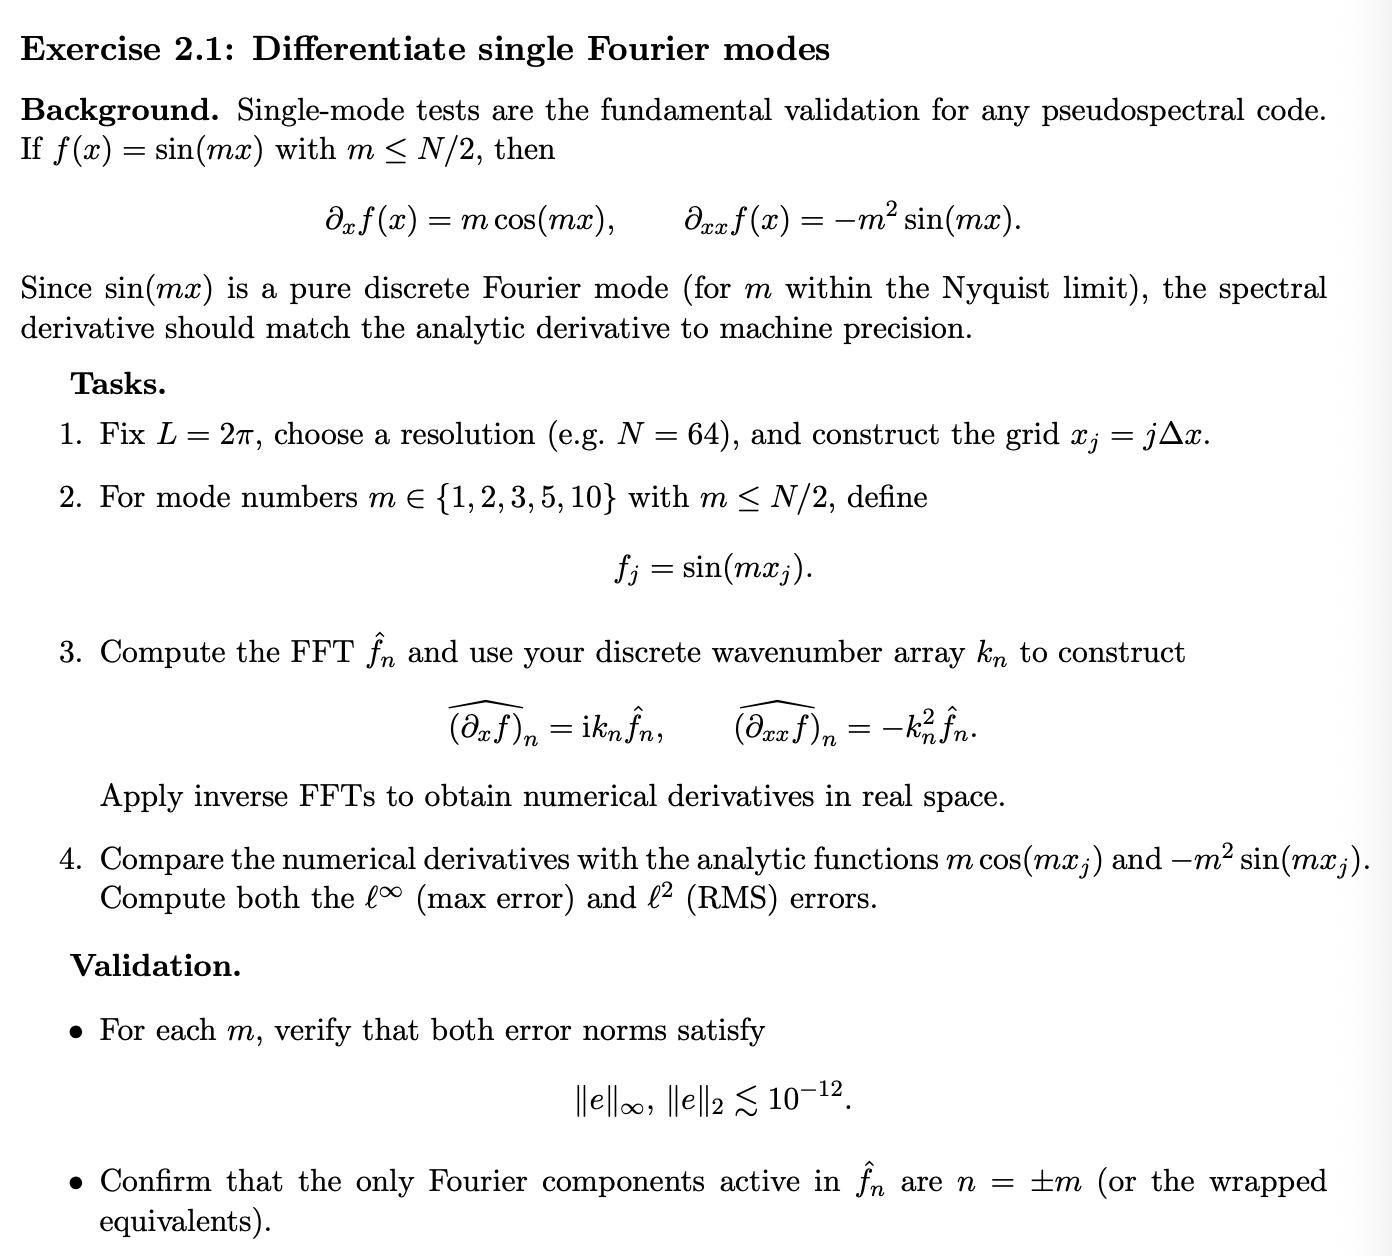

In [ ]:
L = 2*np.pi
N = 64
x_j = np.zeros(N)

def f(m,x):
    return np.sin(m*x)
    
sampled_array = []

for i in range(0,N):
    x_j[i] = i*L/N

print("Grid spacing ∆x: {}".format(L/N))

for mode in [1,2,3,5,10]:
    sampled_array.append(list(map(lambda x: f(mode,x), x_j)))

for i, _ in enumerate(sampled_array[0]):
    print("f_{} = {}".format(i,sampled_array[0][i]))

Grid spacing ∆x: 0.09817477042468103
f_0 = 0.0
f_1 = 0.0980171403295606
f_2 = 0.19509032201612825
f_3 = 0.29028467725446233
f_4 = 0.3826834323650898
f_5 = 0.47139673682599764
f_6 = 0.5555702330196022
f_7 = 0.6343932841636455
f_8 = 0.7071067811865475
f_9 = 0.773010453362737
f_10 = 0.8314696123025452
f_11 = 0.8819212643483549
f_12 = 0.9238795325112867
f_13 = 0.9569403357322088
f_14 = 0.9807852804032304
f_15 = 0.9951847266721968
f_16 = 1.0
f_17 = 0.9951847266721969
f_18 = 0.9807852804032304
f_19 = 0.9569403357322089
f_20 = 0.9238795325112867
f_21 = 0.881921264348355
f_22 = 0.8314696123025453
f_23 = 0.7730104533627371
f_24 = 0.7071067811865476
f_25 = 0.6343932841636455
f_26 = 0.5555702330196022
f_27 = 0.47139673682599786
f_28 = 0.3826834323650899
f_29 = 0.2902846772544624
f_30 = 0.1950903220161286
f_31 = 0.09801714032956083
f_32 = 1.2246467991473532e-16
f_33 = -0.09801714032956059
f_34 = -0.19509032201612836
f_35 = -0.2902846772544621
f_36 = -0.38268343236508967
f_37 = -0.47139673682599764

In [14]:
# Calculation of wavenumber 
f_n = np.fft.fftfreq(N,L/N)
k_n = 2*np.pi*f_n

In [16]:
# FFT 
fft_list = []
derivative_01 = []
derivative_02 = []

for i in range(len(sampled_array)):
    # FFT
    fft_list.append(np.fft.fft(sampled_array[i]))

    # Differentiation
    fft_1 = 1j*k_n*fft_list[i]
    fft_2 = -1*np.square(k_n)*fft_list[i]

    # Inverse FFT - mapping to real space
    i_fft_1 = np.fft.ifft(fft_1)
    i_fft_2 = np.fft.ifft(fft_2)

    derivative_01.append(i_fft_1)
    derivative_02.append(i_fft_2)

In [ ]:
# Comparison between numerical derivative and analytic functions
comp_df = pd.DataFrame(
    columns=[
        'm','Numerical 01','Analytic func 01',
        'Numerical 02','Analytic func 02',
        'Max error 01','RMS error 01',
        'Max error 02','RMS error 02'
    ]
)


for i,m in enumerate([1,2,3,5,10]):
    func_1 = m*np.cos(m*x_j)
    func_2 = -np.square(m)*np.sin(m*x_j)

    error_01 = derivative_01[i] - func_1
    error_02 = derivative_02[i] - func_2

    max_error_01 = la.norm(error_01, np.inf)
    max_error_02 = la.norm(error_02, np.inf)

    rms_error_01 = la.norm(error_01, ord=2)
    rms_error_02 = la.norm(error_02, ord=2)


    comp_df.loc[len(comp_df)] = [m,derivative_01[i],func_1,derivative_02[i],func_2,max_error_01,rms_error_01,max_error_02,rms_error_02
        ]

In [ ]:
# Validation

comp_df['Validation_max_error_01'] = comp_df['Max error 01'] <= 1e-12
comp_df['Validation_max_error_02'] = comp_df['Max error 02'] <= 1e-12

comp_df['Validation_rms_error_01'] = comp_df['RMS error 01'] <= 1e-12
comp_df['Validation_rms_error_02'] = comp_df['RMS error 02'] <= 1e-12


In [34]:
comp_df['RMS error 02']


0    6.248390e-13
1    1.228959e-12
2    2.027465e-12
3    3.868658e-12
4    6.788469e-12
Name: RMS error 02, dtype: float64

In [55]:
# Confirming active fourier components
# Wrapped equivalent = N - m 

# k_shift = np.fft.fftshift(k_n)
index_dict = dict()

for i,m in enumerate([1,2,3,5,10]):
    magnitude_fft = np.abs(fft_list[i])
    indices = np.where(magnitude_fft >= 1e-12)
    index_dict[m] = indices

    print('For m = {}, active fourier components present at n={} and {}'.format(m,m,N-m))


For m = 1, active fourier components present at n=1 and 63
For m = 2, active fourier components present at n=2 and 62
For m = 3, active fourier components present at n=3 and 61
For m = 5, active fourier components present at n=5 and 59
For m = 10, active fourier components present at n=10 and 54


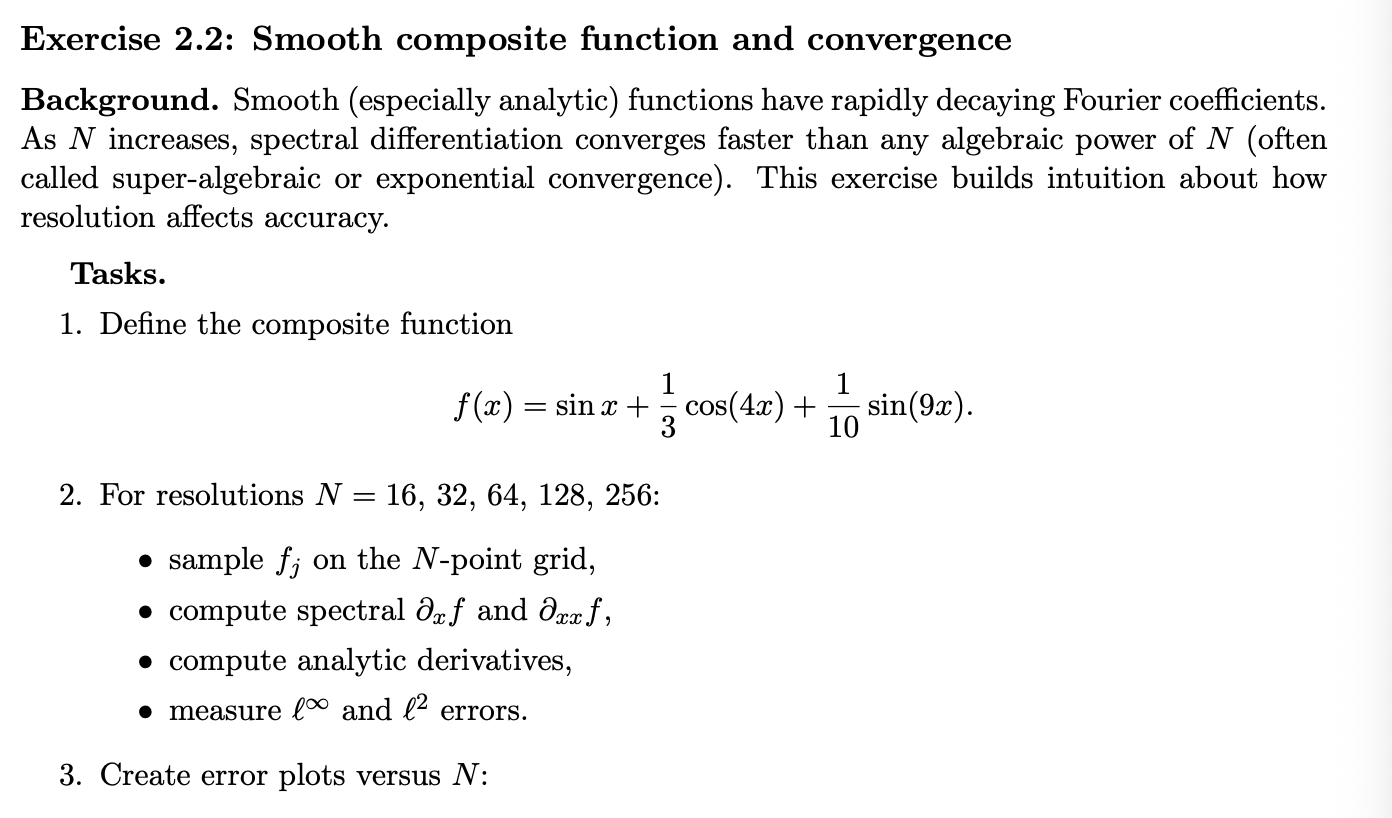
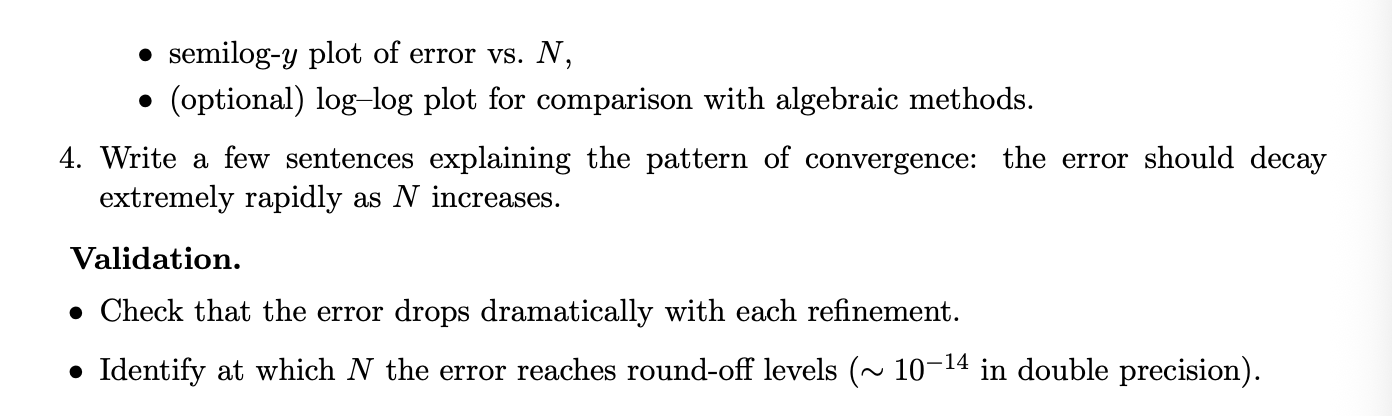

In [106]:
import matplotlib.pyplot as plt

In [ ]:
L = 2*np.pi
resolution = [16,32,64,128,256]

# Comparison between numerical derivative and analytic derivative
comp_df = pd.DataFrame(
    columns=[
        'N','Max error 01','RMS error 01',
        'Max error 02','RMS error 02'
    ]
)

def function_(x):
    return np.sin(x) + (1/3)*np.cos(4*x) + (1/10)*np.sin(9*x)

def analytic_der_01(x):
    return np.cos(x) - (4/3)*np.sin(4*x) + (9/10)*np.cos(9*x)

def analytic_der_02(x):
    return -np.sin(x) - (16/3)*np.cos(4*x) - (81/10)*np.sin(9*x)

for N in resolution:
    sampled_array = []
    x_j = np.zeros(N)

    # Calculation of wavenumber 
    f_n = np.fft.fftfreq(N,L/N)
    k_n = 2*np.pi*f_n

    for i in range(0,N):
        x_j[i] = i*L/N
    print("Grid spacing ∆x for N={} is {}".format(N,L/N))

    sampled_array.append(list(map(lambda x: function_(x), x_j)))
    print("Size of sampled array: {}".format(len(sampled_array[0])))
    
    # FFT 
    fft_list = []

    # FFT
    fft_list.append(np.fft.fft(sampled_array[0]))
        
    # Spectral derivatives + Inverse FFT (for comparison with analytic derivatives)
    spec_fft_1 = np.fft.ifft(1j*k_n*fft_list[0]).real
    spec_fft_2 = np.fft.ifft(-1*np.square(k_n)*fft_list[0]).real

    # Analytic derivatives
    a_der_01 = analytic_der_01(x_j)
    a_der_02 = analytic_der_02(x_j)

    error_01 = spec_fft_1 - a_der_01
    error_02 = spec_fft_2 - a_der_02

    max_error_01 = la.norm(error_01, np.inf)
    max_error_02 = la.norm(error_02, np.inf)

    rms_error_01 = la.norm(error_01, ord=2)
    rms_error_02 = la.norm(error_02, ord=2)

    comp_df.loc[len(comp_df)] = [N,max_error_01,rms_error_01,max_error_02,rms_error_02]

Grid spacing ∆x for N=16 is 0.39269908169872414
Size of sampled array: 16
Grid spacing ∆x for N=32 is 0.19634954084936207
Size of sampled array: 32
Grid spacing ∆x for N=64 is 0.09817477042468103
Size of sampled array: 64
Grid spacing ∆x for N=128 is 0.04908738521234052
Size of sampled array: 128
Grid spacing ∆x for N=256 is 0.02454369260617026
Size of sampled array: 256


In [104]:
comp_df

,N,Max error 01,RMS error 01,Max error 02,RMS error 02
0,16.0,1.600000e+00,4.525483e+00,3.200000e+00,9.050967e+00
1,32.0,7.771561e-15,1.557638e-14,6.972201e-14,1.550139e-13
2,64.0,2.597922e-14,4.721911e-14,4.529710e-13,1.020103e-12
3,128.0,3.064216e-14,1.106098e-13,1.434408e-12,5.076129e-12
4,256.0,6.150636e-14,2.750607e-13,7.487344e-12,2.472752e-11


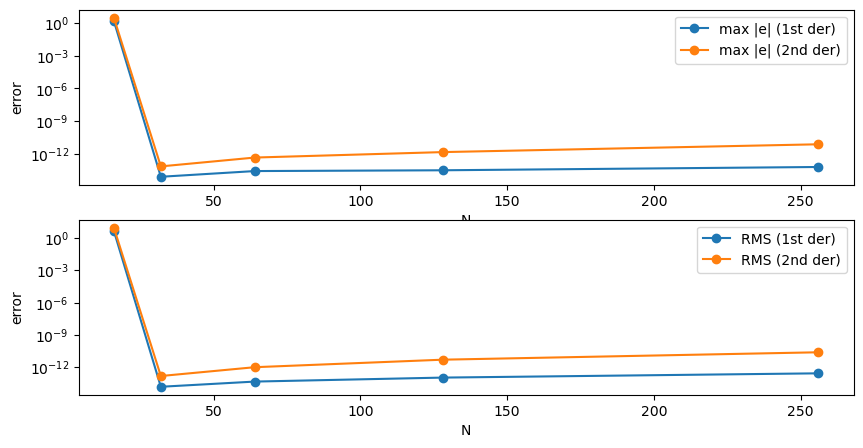

In [116]:
fig, ax = plt.subplots(nrows = 2,ncols = 1,
                      figsize =(10, 5))

ax[0].semilogy(comp_df["N"].to_numpy(), comp_df["Max error 01"].to_numpy(), marker="o", label="max |e| (1st der)")
ax[0].semilogy(comp_df["N"].to_numpy(), comp_df["Max error 02"].to_numpy(), marker="o", label="max |e| (2nd der)")
ax[1].semilogy(comp_df["N"], comp_df["RMS error 01"], marker="o", label="RMS (1st der)")
ax[1].semilogy(comp_df["N"], comp_df["RMS error 02"], marker="o", label="RMS (2nd der)")

ax[0].set_xlabel("N")
ax[0].set_ylabel("error")
ax[0].legend()

ax[1].set_xlabel("N")
ax[1].set_ylabel("error")
ax[1].legend()

plt.show()


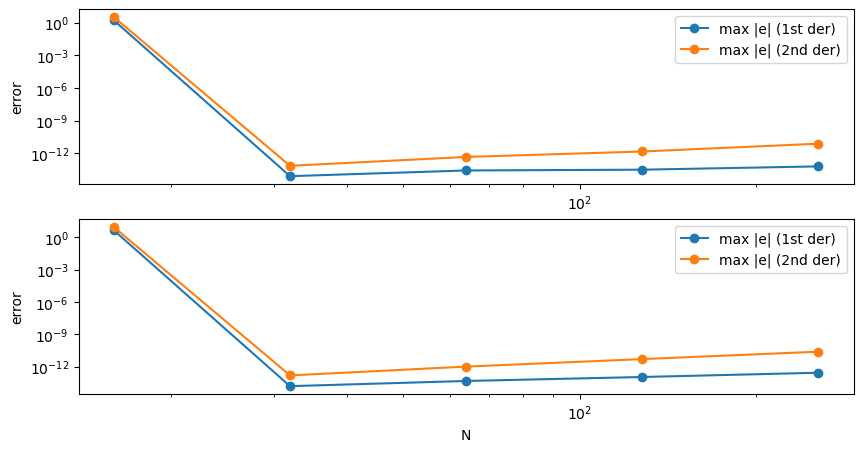

In [123]:
fig, ax = plt.subplots(nrows = 2,ncols = 1,figsize =(10, 5))

ax[0].loglog(resolution, comp_df["Max error 01"].to_numpy(), marker="o", label="max |e| (1st der)")
ax[0].loglog(resolution, comp_df["Max error 02"].to_numpy(), marker="o", label="max |e| (2nd der)")
ax[0].set_xlabel("N")
ax[0].set_ylabel("error")

# ax.grid(True, which="both")
ax[0].legend()

ax[1].loglog(resolution, comp_df["RMS error 01"].to_numpy(), marker="o", label="max |e| (1st der)")
ax[1].loglog(resolution, comp_df["RMS error 02"].to_numpy(), marker="o", label="max |e| (2nd der)")
ax[1].set_xlabel("N")
ax[1].set_ylabel("error")
# ax.grid(True, which="both")
ax[1].legend()

plt.show()

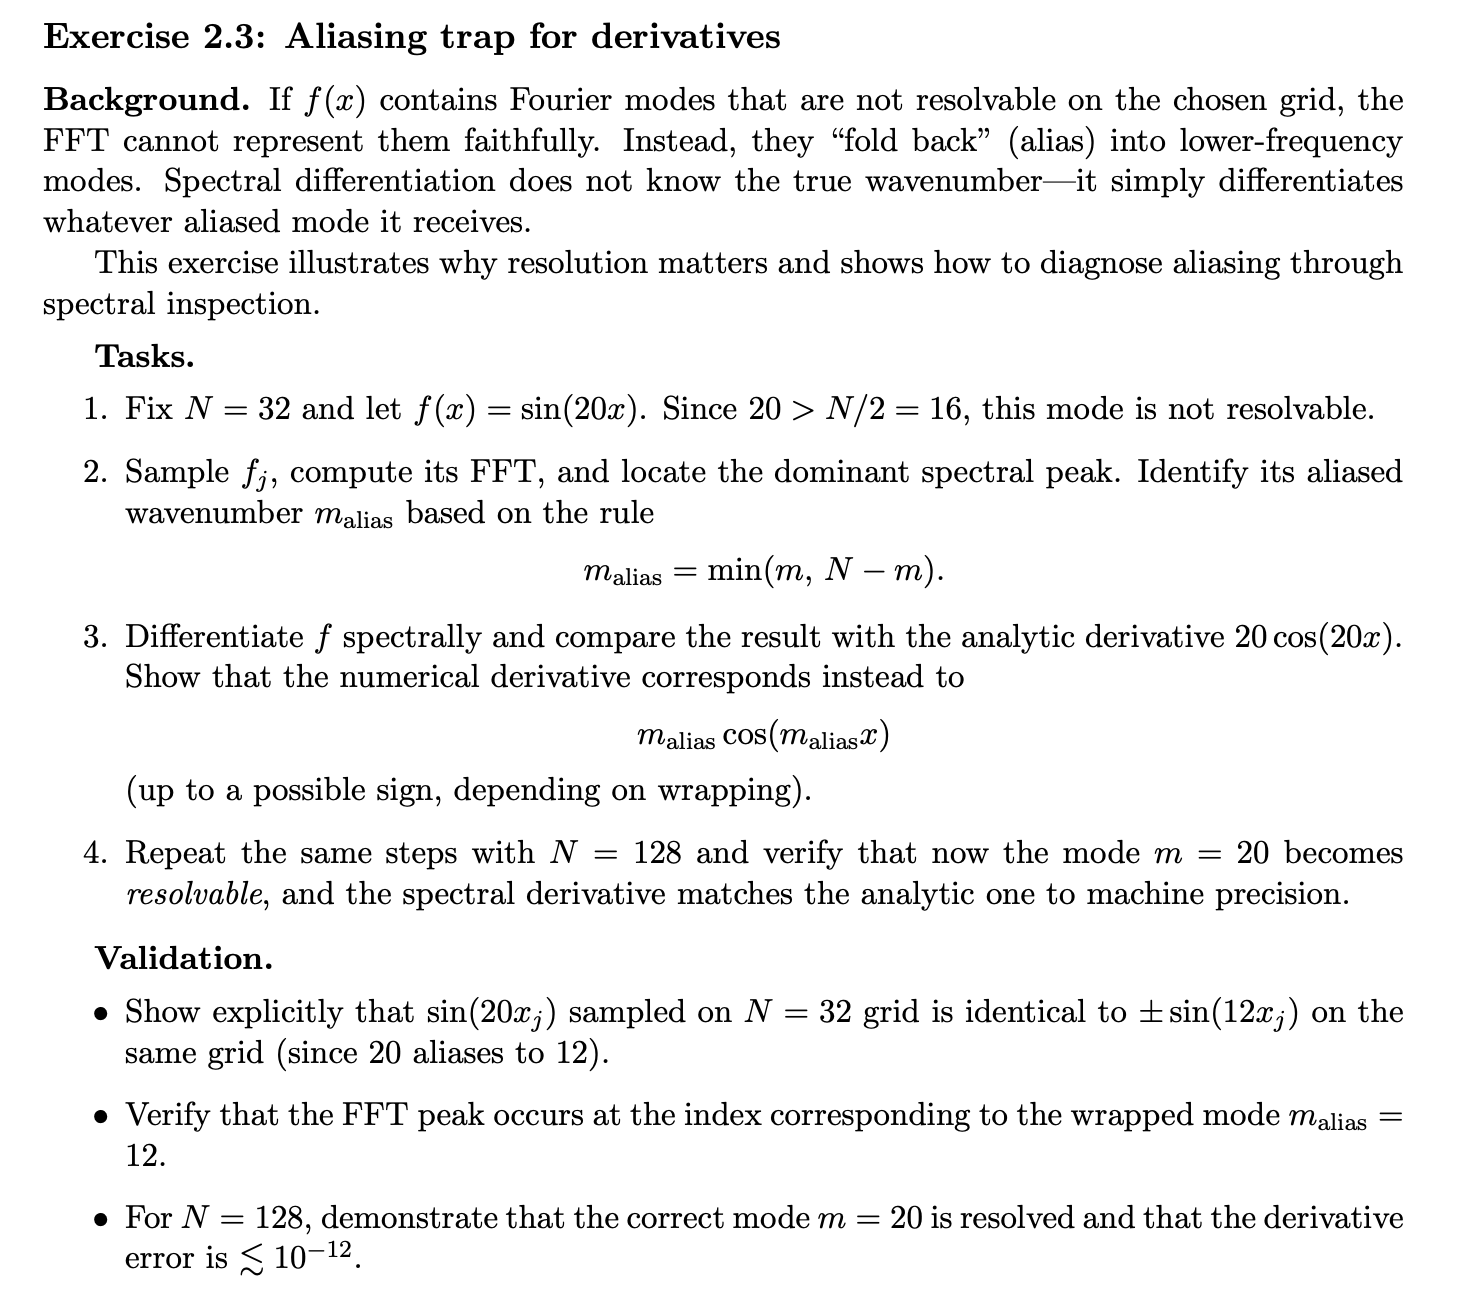

In [164]:
N = 32
L = 2*np.pi

def func_(x):
    return np.sin(20*x)

sampled_array = []
fft_list = []
x_j = np.zeros(N)

for i in range(0,N):
    x_j[i] = i*L/N
print("Grid spacing ∆x for N={} is {}".format(N,L/N))

sampled_array.append(list(map(lambda x: func_(x), x_j)))
print("Size of sampled array: {}".format(len(sampled_array[0])))

# FFT (contains complex numbers)
fft_list.append(np.fft.fft(sampled_array[0]))


Grid spacing ∆x for N=32 is 0.19634954084936207
Size of sampled array: 32


In [173]:
# Dominant peak : maximum from |f_n_hat| (or energy |f_n_hat|^2)
# (because fft values are complex, direct comparison using max is not possible)

idx = np.argsort(np.abs(fft_list[0])**2)[-2:]

# Aliased wavenumber
m_alias = np.min([20,32-20]) # 20 because sin(20x) peaks at + or - 20
print(f"The dominant peaks will be at +{m_alias} and -{m_alias}")

# Calculation of wavenumber 
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
print(k_n)

# Dominant peaks (wavenumbers)
print(k_n[idx])

The dominant peaks will be at +12 and -12
[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.
  -4.  -3.  -2.  -1.]
[ 12. -12.]


In [ ]:
# Spectral derivatives + Inverse FFT (for comparison with analytic derivatives)
spec_fft_1 = np.fft.ifft(1j*k_n*fft_list[0]).real
anal_der = 20*np.cos(20*x_j)


In [178]:
print(la.norm(spec_fft_1-anal_der,ord=2))
print(la.norm(spec_fft_1-anal_der,ord=np.inf))

127.99999999999994
32.00000000000007


In [184]:
validate = {k_n[id]:k_n[id]*np.cos(k_n[id]*x_j) for id in idx}

error_plus = la.norm(np.array(validate[12]) - spec_fft_1,ord=2)
error_minus = la.norm(np.array(validate[-12]) - spec_fft_1,ord=2)

In [186]:
error_plus

np.float64(96.00000000000011)

In [ ]:
error_minus # machine precision

np.float64(3.637177315967596e-13)

In [192]:
N = 128
L = 2*np.pi

def func_(x):
    return np.sin(20*x)

sampled_array = []
fft_list = []
x_j = np.zeros(N)

for i in range(0,N):
    x_j[i] = i*L/N
print("Grid spacing ∆x for N={} is {}".format(N,L/N))

sampled_array.append(list(map(lambda x: func_(x), x_j)))
print("Size of sampled array: {}".format(len(sampled_array[0])))

# FFT (contains complex numbers)
fft_list.append(np.fft.fft(sampled_array[0]))

# Spectral derivatives + Inverse FFT (for comparison with analytic derivatives)
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
spec_fft_1 = np.fft.ifft(1j*k_n*fft_list[0]).real
anal_der = 20*np.cos(20*x_j)

print(la.norm(spec_fft_1-anal_der,ord=2))
print(la.norm(spec_fft_1-anal_der,ord=np.inf))


Grid spacing ∆x for N=128 is 0.04908738521234052
Size of sampled array: 128
1.5874962700529883e-12
3.632649736573512e-13


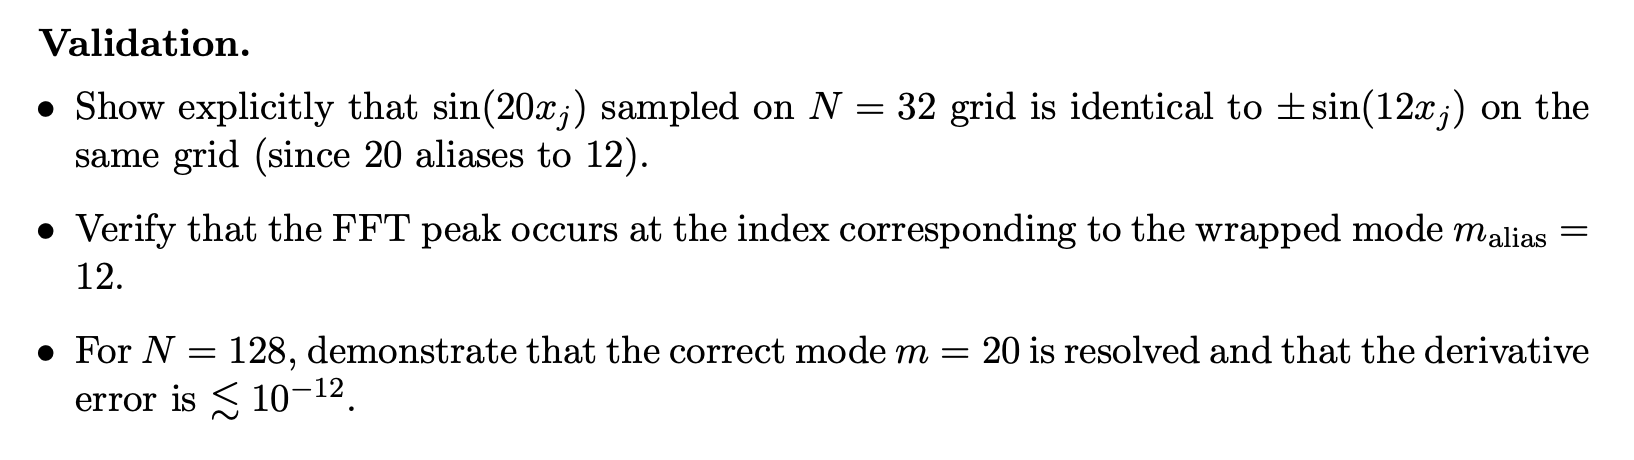

In [204]:
# Validation

N = 32
L = 2*np.pi

def func_01(m, x):
    return np.sin(m*x)

x_j = np.zeros(N)

for i in range(0,N):
    x_j[i] = i*L/N
print("Grid spacing ∆x for N={} is {}".format(N,L/N))

sampled_array = func_01(20, x_j)
print("Size of sampled array: {}".format(len(sampled_array)))

# FFT (contains complex numbers)
fft_list = np.fft.fft(sampled_array).real

fft_compare = np.fft.fft(func_01(12, x_j)).real
la.norm(fft_list-fft_compare,ord=2)


Grid spacing ∆x for N=32 is 0.19634954084936207
Size of sampled array: 32


np.float64(7.304061968136868e-14)

In [197]:
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
k_n

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15., -16., -15., -14., -13., -12., -11.,
       -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.])

In [203]:
idx = np.argsort(np.abs(fft_list)**2)[-2:]
k_n[idx]

array([ 12., -12.])

In [209]:
# Validation

N = 128
L = 2*np.pi

def func_01(m, x):
    return np.sin(m*x)

x_j = np.zeros(N)

for i in range(0,N):
    x_j[i] = i*L/N
print("Grid spacing ∆x for N={} is {}".format(N,L/N))

sampled_array = func_01(20, x_j)
print("Size of sampled array: {}".format(len(sampled_array)))

k_n = 2*np.pi*np.fft.fftfreq(N,L/N)

# FFT (contains complex numbers)
fft_list = np.fft.fft(sampled_array)
spec_der = np.fft.ifft(1j*k_n*fft_list).real

anal_de = 20*np.cos(20*x_j)

la.norm(spec_der-anal_de,ord=2)/np.sqrt(N)


Grid spacing ∆x for N=128 is 0.04908738521234052
Size of sampled array: 128


np.float64(1.4031617220785234e-13)